# Libraries

In [29]:
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
from getpass import getpass
from sqlalchemy.engine import URL


In [30]:
db_password = getpass("Oracle password: ")

engine = create_engine(
    URL.create(
        drivername="oracle+oracledb",
        username="Devlab",
        password=db_password,
        host="localhost",
        port=1521,
        query={"service_name": "XEPDB1"},
    )
)

In [31]:
df = pd.read_sql("SELECT COUNT(*) AS count_of_rows FROM superstore", engine)
print(df)

   count_of_rows
0           9994


# 10 questions

In [32]:
q1_sql = """
SELECT count(*) AS row_count,
       count(DISTINCT customer_id) AS count_of_customers,
       count(DISTINCT product_id) AS count_of_products,
       min(to_date(order_date,'MM,DD,YYYY')) AS min_date,
       max(to_date(order_date,'MM,DD,YYYY')) AS max_date
FROM superstore
"""

q1_result = pd.read_sql(q1_sql, engine)
q1_result

,row_count,count_of_customers,count_of_products,min_date,max_date
0,9994,793,1862,2014-01-03,2017-12-30


In [33]:
q2_sql = """
select 
    count(*) - count(row_id) as null_row_id,
    count(*) - count(order_id) as null_order_id,
    count(*) - count(ORDER_DATE) as null_order_date,
    count(*) - count(SHIP_DATE) as null_ship_date,
    count(*) - count(SHIP_MODE) as null_ship_mode,
    count(*) - count(CUSTOMER_ID) as null_customer_id,
    count(*) - count(CUSTOMER_NAME) as null_customer_name,
    count(*) - count(SEGMENT) as null_segment,
    count(*) - count(COUNTRY) as null_country,
    count(*) - count(CITY) as null_city,
    count(*) - count(STATE) as null_state,
    count(*) - count(POSTAL_CODE) as null_postal_code,
    count(*) - count(REGION) as null_region,
    count(*) - count(PRODUCT_ID) as null_product_id,
    count(*) - count(CATEGORY) as null_category,
    count(*) - count(SUB_CATEGORY) as null_sub_category,
    count(*) - count(PRODUCT_NAME) as null_product_name,
    count(*) - count(SALES ) as null_sales,
    count(*) - count(QUANTITY ) as null_quantity,
    count(*) - count(DISCOUNT) as null_discount,
    count(*) - count(PROFIT)  as null_profit
 from SUPERSTORE
"""

q2_result = pd.read_sql(q2_sql,engine)
q2_result

,null_row_id,null_order_id,null_order_date,null_ship_date,null_ship_mode,null_customer_id,null_customer_name,null_segment,null_country,null_city,...,null_postal_code,null_region,null_product_id,null_category,null_sub_category,null_product_name,null_sales,null_quantity,null_discount,null_profit
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
q3_sql = """
select 
    ORDER_ID,
    product_id, 
    count(*) as count_of_orders 
from SUPERSTORE
group by ORDER_ID,PRODUCT_ID
having count(*)>1"""

q3_result = pd.read_sql(q3_sql,engine)

q3_result

,order_id,product_id,count_of_orders
0,CA-2016-137043,FUR-FU-10003664,2
1,CA-2016-140571,OFF-PA-10001954,2
2,CA-2016-129714,OFF-PA-10001970,2
3,US-2014-150119,FUR-CH-10002965,2
4,CA-2015-103135,OFF-BI-10000069,2
5,CA-2017-118017,TEC-AC-10002006,2
6,CA-2017-152912,OFF-ST-10003208,2
7,US-2016-123750,TEC-AC-10004659,2


In [35]:
q4_sql = """
SELECT SHIP_MODE,
    ROUND(AVG(TO_DATE(SHIP_DATE, 'MM,DD,YYYY') - TO_DATE(ORDER_DATE, 'MM,DD,YYYY')), 2) AS avg_days_to_ship
FROM SUPERSTORE
GROUP BY SHIP_MODE
ORDER BY avg_days_to_ship"""


q4_result = pd.read_sql(q4_sql,engine)
q4_result

,ship_mode,avg_days_to_ship
0,Same Day,0.04
1,First Class,2.18
2,Second Class,3.24
3,Standard Class,5.01


In [36]:
q5_sql = """
select 
    region, 
    category, 
    SUB_CATEGORY,
    sum(sales) as total_sales,
    sum(PROFIT) as total_profit,
    round(sum(profit)/nullif(sum(sales),0),3) as profit_margin
from SUPERSTORE
group by region,category,sub_category
order by total_profit asc"""

q5_result = pd.read_sql(q5_sql,engine)
q5_result

,region,category,sub_category,total_sales,total_profit,profit_margin
0,East,Furniture,Tables,39139.807,-11025.3801,-0.282
1,South,Furniture,Tables,43916.192,-4623.0579,-0.105
2,Central,Furniture,Furnishings,15254.370,-3906.2168,-0.256
3,Central,Furniture,Tables,39154.971,-3559.6504,-0.091
4,Central,Office Supplies,Appliances,23582.033,-2638.6175,-0.112
...,...,...,...,...,...,...
63,Central,Technology,Copiers,37259.570,15608.8413,0.419
64,West,Office Supplies,Binders,55961.113,16096.8016,0.288
65,West,Technology,Accessories,61114.116,16484.5983,0.270
66,East,Technology,Copiers,53219.462,17022.8418,0.320


In [37]:
q6_sql = """
with subcategory_profit as (
    select 
        sub_category,
        sum(profit) as profit_subcategory2 
    from SUPERSTORE
    group by sub_category
),


ranked as (
    select 
    sub_category,
    profit_subcategory2,
    rank() over(order by profit_subcategory2 asc) as profit_subcategory2_asc,
    rank() over(order by profit_subcategory2 desc) as profit_subcategory2_desc
    from subcategory_profit
)

SELECT
    sub_category,
    profit_subcategory2,
    CASE
        WHEN profit_subcategory2_desc <= 5 THEN 'TOP'
        WHEN profit_subcategory2_asc  <= 5 THEN 'BOTTOM'
    END AS rank_group
FROM ranked
WHERE profit_subcategory2_desc <= 5
   OR profit_subcategory2_asc <= 5
ORDER BY profit_subcategory2 DESC"""


q6_result = pd.read_sql(q6_sql,engine)
q6_result

,sub_category,profit_subcategory2,rank_group
0,Copiers,55617.8249,TOP
1,Phones,44515.7306,TOP
2,Accessories,41936.6357,TOP
3,Paper,34053.5693,TOP
4,Binders,30221.7633,TOP
5,Machines,3384.7569,BOTTOM
6,Fasteners,949.5182,BOTTOM
7,Supplies,-1189.0995,BOTTOM
8,Bookcases,-3472.5560,BOTTOM
9,Tables,-17725.4811,BOTTOM


In [38]:
q7_sql = """
SELECT
    discount_band,
    COUNT(order_id)       AS order_count,
    ROUND(AVG(profit), 2) AS avg_profit,
    ROUND(SUM(profit), 2) AS total_profit
FROM (
    SELECT
        order_id,
        profit,
        CASE
            WHEN discount = 0                    THEN 'zero'
            WHEN discount BETWEEN 0.01 AND 0.2   THEN 'lower'
            WHEN discount BETWEEN 0.21 AND 0.4   THEN 'middle'
            WHEN discount > 0.4                  THEN 'high'
            ELSE 'unknown'  -- catches NULL discount, kept separate on purpose
        END AS discount_band
    FROM superstore
)
GROUP BY discount_band
ORDER BY discount_band"""


q7_result = pd.read_sql(q7_sql,engine)
q7_result

,discount_band,order_count,avg_profit,total_profit
0,high,933,-106.71,-99558.59
1,lower,3803,26.50,100785.47
2,middle,460,-77.86,-35817.47
3,zero,4798,66.90,320987.60


In [39]:
q8_sql = """
with absolute as (
select extract( year from to_date(order_date,'mm,dd,yyyy')) as year, sales from SUPERSTORE)

select 
    year,
    sum(sales) total_sales,
    sum(sales) - lag(sum(sales)) OVER (ORDER BY year) AS yoy_absolute,
    round((sum(sales)- lag(sum(sales)) OVER (ORDER BY year))*100/NULLIF(lag(sum(sales)) OVER (ORDER BY year), 0)) AS yoy_percentage
from absolute
group by year
order by year"""

q8_result = pd.read_sql(q8_sql,engine)
q8_result

,year,total_sales,yoy_absolute,yoy_percentage
0,2014,484247.4981,NaN,NaN
1,2015,470532.5090,-13714.9891,-3.0
2,2016,609205.5980,138673.0890,29.0
3,2017,733215.2552,124009.6572,20.0


In [40]:
q9_sql = """
select 
    SUB_CATEGORY,
    sum(profit) as total_profit,
    sum(SALES) as total_sales,
    round(sum(sales)*100/(select sum(sales) from SUPERSTORE),2) as revenue_share
from SUPERSTORE
group by SUB_CATEGORY
having sum(profit) <0"""


q9_result = pd.read_sql(q9_sql,engine)
q9_result

,sub_category,total_profit,total_sales,revenue_share
0,Tables,-17725.4811,206965.5320,9.01
1,Supplies,-1189.0995,46673.5380,2.03
2,Bookcases,-3472.5560,114879.9963,5.00


In [41]:
q10_sql = """
select 
    customer_name,
    customer_id,
    sum(profit) as lifetime_profit,
    count(distinct order_id) as count_of_orders ,
    sum(sales) as total_sales,
    round(sum(sales)/count(distinct order_id),2) as AOV 
from SUPERSTORE
group by customer_name,customer_id
order by sum(profit) desc
fetch first 10 rows only"""

q10_result = pd.read_sql(q10_sql,engine)
q10_result

,customer_name,customer_id,lifetime_profit,count_of_orders,total_sales,aov
0,Tamara Chand,TC-20980,8981.3239,5,19052.218,3810.44
1,Raymond Buch,RB-19360,6976.0959,6,15117.339,2519.56
2,Sanjit Chand,SC-20095,5757.4119,9,14142.334,1571.37
3,Hunter Lopez,HL-15040,5622.4292,6,12873.298,2145.55
4,Adrian Barton,AB-10105,5444.8055,10,14473.571,1447.36
5,Tom Ashbrook,TA-21385,4703.7883,4,14595.620,3648.91
6,Christopher Martinez,CM-12385,3899.8904,4,8954.020,2238.51
7,Keith Dawkins,KD-16495,3038.6254,12,8181.256,681.77
8,Andy Reiter,AR-10540,2884.6208,6,6608.448,1101.41
9,Daniel Raglin,DR-12940,2869.0760,8,8350.868,1043.86


In [42]:
final_sql = """
WITH yearly AS (
    SELECT EXTRACT(YEAR FROM TO_DATE(order_date, 'MM,DD,YYYY')) AS year,
           sales,
           profit
    FROM superstore
)
SELECT year,
       ROUND(SUM(sales), 0)                         AS total_sales,
       ROUND(SUM(profit), 0)                        AS total_profit,
       ROUND(SUM(profit) / NULLIF(SUM(sales), 0), 3) AS profit_margin
FROM yearly
GROUP BY year
ORDER BY year"""

final_result = pd.read_sql(final_sql,engine)
final_result

,year,total_sales,total_profit,profit_margin
0,2014,484247,49544,0.102
1,2015,470533,61619,0.131
2,2016,609206,81795,0.134
3,2017,733215,93439,0.127


# Visualation

In [43]:
q_plot6_sql = """
    select 
        sub_category,
        sum(profit) as profit_subcategory2 
    from SUPERSTORE
    group by sub_category"""

subcat_profit  = pd.read_sql(q_plot6_sql,engine)
subcat_profit

,sub_category,profit_subcategory2
0,Accessories,41936.6357
1,Binders,30221.7633
2,Paper,34053.5693
3,Furnishings,13059.1436
4,Chairs,26590.1663
5,Art,6527.7870
6,Phones,44515.7306
7,Storage,21278.8264
8,Appliances,18138.0054
9,Envelopes,6964.1767


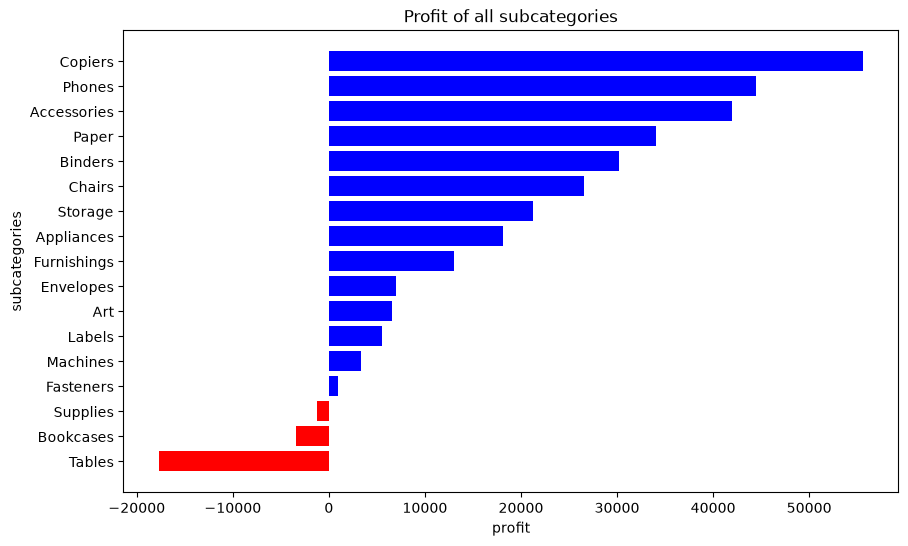

In [44]:
df_sorted = subcat_profit.sort_values("profit_subcategory2")


colors = ["red" if p<0 else 'blue' for p in df_sorted['profit_subcategory2']]
plt.figure(figsize=(10,6))
plt.barh(df_sorted["sub_category"], df_sorted["profit_subcategory2"], color=colors)
plt.title("Profit of all subcategories")
plt.xlabel("profit")
plt.ylabel("subcategories")
plt.show()


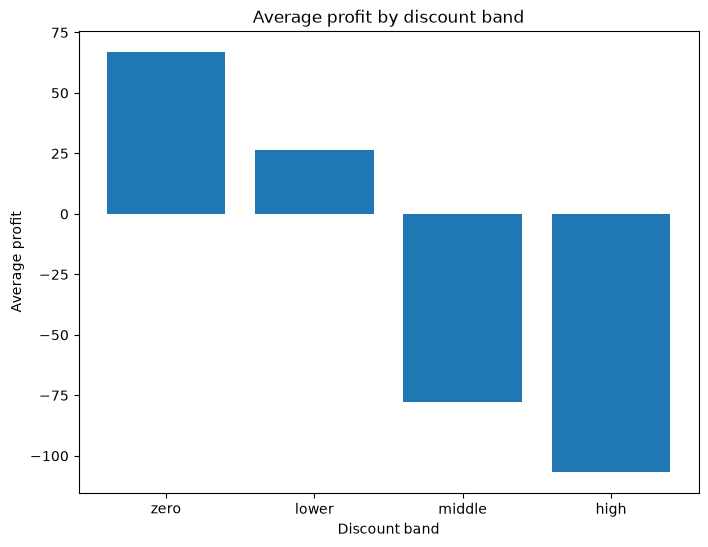

In [45]:
band_order = ['zero', 'lower', 'middle', 'high']
q7_result['discount_band'] = pd.Categorical(q7_result['discount_band'], categories=band_order, ordered=True)
q7_result_sorted = q7_result.sort_values('discount_band')


plt.figure(figsize=(8,6))
plt.bar(q7_result_sorted["discount_band"],q7_result_sorted['avg_profit'])
plt.title('Average profit by discount band')
plt.xlabel('Discount band')
plt.ylabel('Average profit')
plt.show()

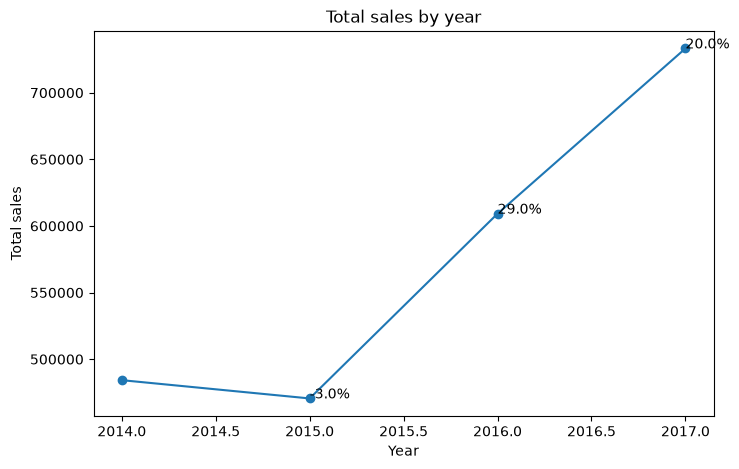

In [46]:
plt.figure(figsize=(8,5))
plt.plot(q8_result['year'], q8_result['total_sales'], marker='o')

for i, row in q8_result.iterrows():
    label = f"{row['yoy_percentage']}%" if pd.notna(row['yoy_percentage']) else ""
    plt.annotate(label, (row['year'], row['total_sales']))

plt.title("Total sales by year")
plt.xlabel("Year")
plt.ylabel("Total sales")
plt.show()

In [47]:
q8_result

,year,total_sales,yoy_absolute,yoy_percentage
0,2014,484247.4981,NaN,NaN
1,2015,470532.5090,-13714.9891,-3.0
2,2016,609205.5980,138673.0890,29.0
3,2017,733215.2552,124009.6572,20.0


# insights

In [48]:
q7_result_sorted

,discount_band,order_count,avg_profit,total_profit
3,zero,4798,66.90,320987.60
1,lower,3803,26.50,100785.47
2,middle,460,-77.86,-35817.47
0,high,933,-106.71,-99558.59


In Q7, the average profit in the 41%+ discount band is -106.7, while in the 0% band it is +66.9. From this we can conclude that when the discount band is zero, i.e. no discount is applied, our profit is highest, and when the discount band is high, our profit is lowest — meaning that as the discount increases, our profit decreases. Action to take: we can increase our profit by reducing discounts. The table also shows that the largest share of profit comes when the discount band is zero. This shows a correlation, not a causal relationship.

In [49]:
q8_result

,year,total_sales,yoy_absolute,yoy_percentage
0,2014,484247.4981,NaN,NaN
1,2015,470532.5090,-13714.9891,-3.0
2,2016,609205.5980,138673.0890,29.0
3,2017,733215.2552,124009.6572,20.0


Q8: The sales trend shows a clear recovery after a slight decline in 2015. Sales decreased by 3.0% in 2015, but then increased significantly by 29.0% in 2016 and a further 20.0% in 2017. The strongest absolute year-over-year increase occurred in 2016 (138673.089), while 2017 maintained strong positive growth with an additional 124009.6572.

Business Insight: The company moved from a short-term sales decline in 2015 to sustained double-digit growth in 2016–2017. However, the reduction in growth rate from 29.0% to 20.0% indicates that sales growth began to moderate in 2017, making it important to evaluate whether this trend was accompanied by similar improvements in profitability.

In [50]:
q9_result

,sub_category,total_profit,total_sales,revenue_share
0,Tables,-17725.4811,206965.5320,9.01
1,Supplies,-1189.0995,46673.5380,2.03
2,Bookcases,-3472.5560,114879.9963,5.00


**Q9 Insight**

Tables, Bookcases, and Supplies generate negative profit: -22.4K in total. They account for 16.0% of revenue (368.5K / 2.30M), while the overall business margin is 12.5%.

Tables generates 79% of the loss (-17.7K, margin -8.6%, 9.0% revenue share). At 0 discount, its margin is +18.5%, while at discounts above 20% it loses -30.7K.
Bookcases (-3.5K, margin -3.0%) shows the same pattern: +6.1K at 0 discount, -11.1K above 20%.
Supplies (-1.2K, margin -2.5%) does not look like a discount problem, since it has no discounts above 20%. Pricing or cost of goods should be checked.

Recommendation: cap discounts at 20% for Tables and Bookcases. Without these 3 sub-categories, total profit would be at most 7.8% higher (an upper bound; sales volume would also change).

Note: discount and loss appear together, but correlation ≠ causation.

In [51]:
q10_result

,customer_name,customer_id,lifetime_profit,count_of_orders,total_sales,aov
0,Tamara Chand,TC-20980,8981.3239,5,19052.218,3810.44
1,Raymond Buch,RB-19360,6976.0959,6,15117.339,2519.56
2,Sanjit Chand,SC-20095,5757.4119,9,14142.334,1571.37
3,Hunter Lopez,HL-15040,5622.4292,6,12873.298,2145.55
4,Adrian Barton,AB-10105,5444.8055,10,14473.571,1447.36
5,Tom Ashbrook,TA-21385,4703.7883,4,14595.620,3648.91
6,Christopher Martinez,CM-12385,3899.8904,4,8954.020,2238.51
7,Keith Dawkins,KD-16495,3038.6254,12,8181.256,681.77
8,Andy Reiter,AR-10540,2884.6208,6,6608.448,1101.41
9,Daniel Raglin,DR-12940,2869.0760,8,8350.868,1043.86


Q10 Insight

The top 10 customers generate 50.2K profit (17.5% of total profit), yet they make up only 1.3% of the 793 customers and 5.3% of sales. Their margin is 41%, versus a business average of 12.5%.

Key finding: the top 3 customers' profit comes almost entirely from a single order: Tamara Chand 97.6%, Raymond Buch 96.5%, Sanjit Chand 81.1%. In other words, "lifetime profit" ranks one-off large purchases above loyal customers.

Flip side: 155 customers (19.5%) have negative profit, -71.2K in total. The #1 customer by sales, Sean Miller (25.0K), is at a loss of -1,981.

Recommendation: segment customers into "repeat buyers" and "one-off large orders", and build retention around recurring profit.

Note: high profit and high margin appear together, but correlation ≠ causation. The cause may be product type, which should be checked separately.

# Final conclusion

In [52]:
final_result

,year,total_sales,total_profit,profit_margin
0,2014,484247,49544,0.102
1,2015,470533,61619,0.131
2,2016,609206,81795,0.134
3,2017,733215,93439,0.127


## Final insight
**Scope:** 9,994 order lines, 5,009 orders, 793 customers, 2014–2017. Total sales 2.30M, profit 286.4K, overall margin 12.5%. Data quality is good: no NULLs, and only 1 fully identical line among 8 repeated order-product pairs.

**1.** Sales fell 2.8% in 2015, then grew 29.5% (2016) and 20.4% (2017). Profit grew every year, but margin peaked at 13.4% in 2016 and slipped to 12.7% in 2017, as 2017 profit growth (14.2%) lagged sales growth (20.4%).

**2.** Lines with 0% discount earn +321.0K profit, while lines above 20% discount lose -135.4K. These lines are only 13.9% of order lines (15.8% of sales). Average profit per line falls from +66.9 (no discount) to -106.7 (41%+).

**3..** Tables, Bookcases and Supplies lose -22.4K combined on 16.0% of revenue. Tables alone is 79% of that loss, with a +18.5% margin at 0% discount but -30.7K above 20% discount. Bookcases follows the same pattern. Supplies has no discounts above 20%, so its problem is likely pricing or cost. Machines is a watchlist item: 8.2% of revenue at only a 1.8% margin.

**4..** The top 10 customers generate 17.5% of profit at a 41% margin, and the top 3 earned 81–98% of their profit from a single order. Meanwhile 155 customers (19.5%) are unprofitable, -71.2K in total.

**Recommendations**
1. Cap discounts at 20% for Tables and Bookcases; start with the East region and measure the effect on volume.
2. Review pricing and unit cost for Supplies; monitor Machines.
3. Segment customers into repeat buyers and one-off large orders, and base retention on recurring profit.
4. Track yearly margin, not only sales growth.

